# Group 42

Main

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import asyncio

from thymio import Thymio
from vision import Vision

import motion_controll
import filtering
import local_nav
import global_nav
import utils

In [ ]:
thymio = Thymio(pos_init=[0, 0], orient=0)
await thymio._connect_to_thymio_()
thymio.stop()

Local nav tests

In [ ]:
thymio.nav_mode = "LOCAL"
while True: 
    await thymio.update_ir()
    # is_object = local_nav.is_object(thymio)
    # if(is_object):
    #     print("object detected")
    print(str(thymio.ir_sensors) + "                     ", end="\r")
    # avoid_right = local_nav.avoid_right(thymio, grid)
    # local_nav.avoid_obstacle(thymio, 0, 0, avoid_right)
# await thymio.update_ir()
# print(thymio.ir_sensors)

Motion controll testing

In [ ]:
thymio.pos = [20,20]
thymio.orient = 0
goal = [22,25]
print(motion_controll.follow_path(thymio, goal))

In [ ]:
await thymio.unlock()

## Main Loop

In [ ]:
thymio.stop()

(0.5145688199589397, 0.542516637974837) -3.0433187


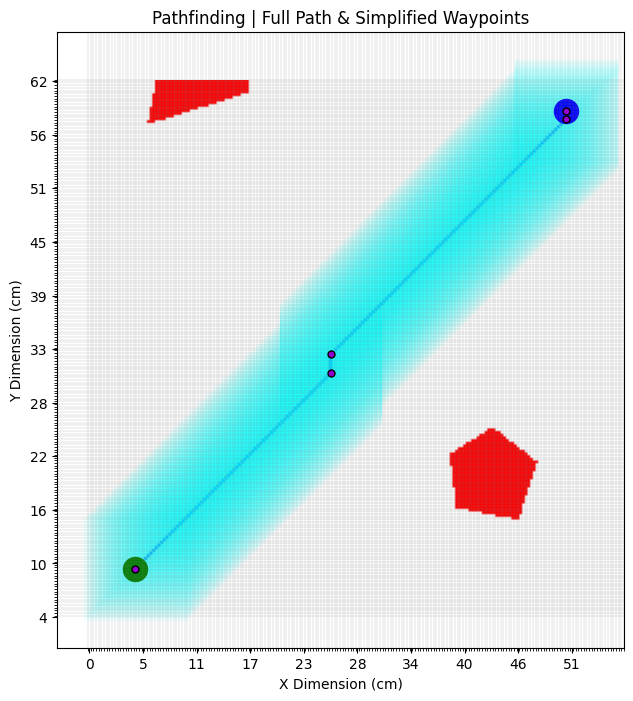

Thymio connected


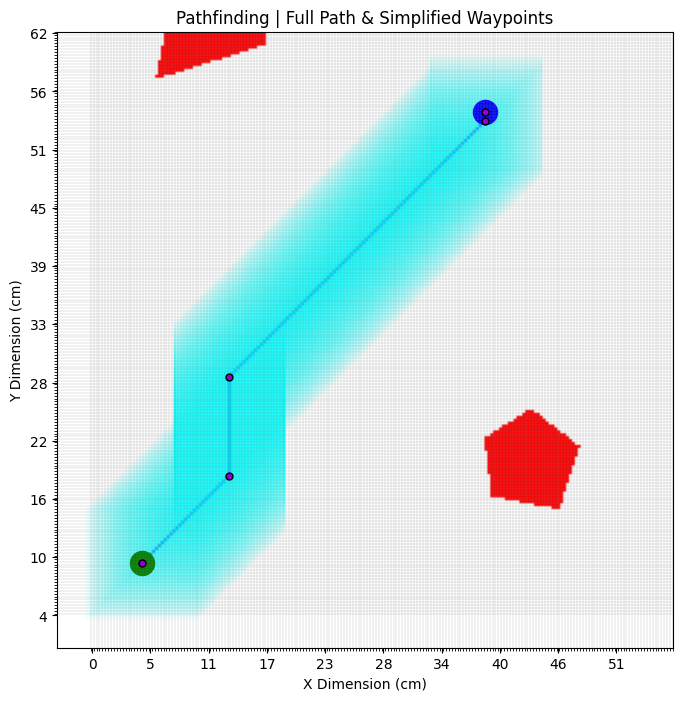

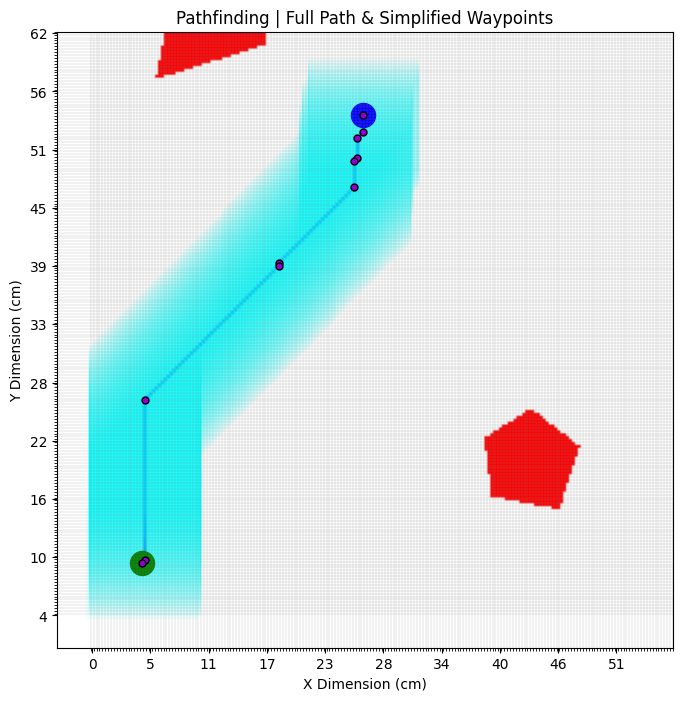

Couldn't locate robot so exiting geRobotPoseAndVisualise function


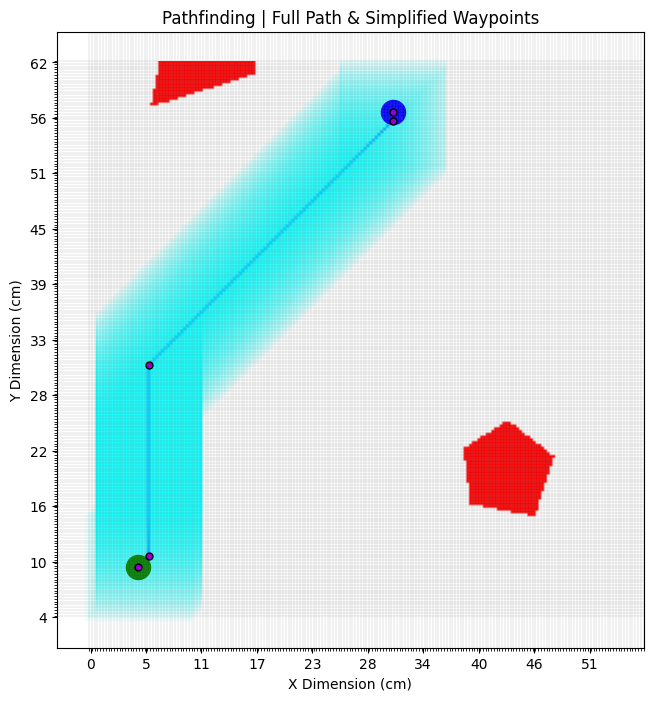

Goal reached


In [1]:
# External modules import
import matplotlib.pyplot as plt
import numpy as np
import cv2
import time
import asyncio

# Internal modules and thymio class import
from thymio import Thymio
from vision import Vision
import motion_controll
import filtering
import local_nav
import global_nav
import utils

# Constants
GL_NAV_CHANGE_THLD = 40  # Number of cycles without obstacle to switch back to global navigation

# Initalisation of the grid
visionInstance = Vision() # Calls getEnvironment which stores the arena and creates the grid
# visionInstance.display_grid()

# Get cell size for coordinate conversions
cell_size_cm = visionInstance.getCellSizeCm()

# Get start position and orientation
ret, frame = visionInstance.cap.read() #Taking a single image to find the start pos of the robot
if not ret:
    raise ValueError("Camera failed to capture the frame.")

#start_pos, start_orient = visionInstance.getRobotPose(frame)
start_pos, start_orient = visionInstance.getInitialRobotPose()
print(start_pos, start_orient)

# Convert to grid coordinates (start_pos is in meters, convert to cm first)
if start_pos:
    start_cell = utils.real_to_grid((start_pos[0]*100, start_pos[1]*100))
    # print(f"start: {start_cell}")
    goal_cell = utils.real_to_grid((5, 5))  # Goal in cm
    # print(f"goal: {goal_cell}")
    # visionInstance.display_grid(start_cell, goal_cell)

# Get the grid from vision
grid = visionInstance.grid

# Find path to goal (mode = "a_star" or "djikstra")
# 0 for djikstra, 1 for a*
path_find_mode = 0
path, expanded_grid = global_nav.find_path(path_find_mode, grid, start_cell, goal_cell)


# Initialisation of the thymio and connexion
thymio = Thymio(pos_init=start_pos, orient=start_orient)
await thymio._connect_to_thymio_()

thymio.stop()

# Local nav variables
gl_nav_change_cntr = 0
avoid_right = True

while(True):
    start_loop_time = time.time()
    await thymio.update_ir()
    # print(thymio.ir_sensors)
    is_object = local_nav.is_object(thymio)
    # is_object = False
    nav_mode_change = False

    if(is_object):
        gl_nav_change_cntr = 0
        if(thymio.nav_mode=="GLOBAL"):
            avoid_right = local_nav.avoid_right(thymio, grid)
            nav_mode_change = True
            thymio.nav_mode = "LOCAL"
    
    if(not is_object and thymio.nav_mode=="LOCAL"):
        gl_nav_change_cntr += 1
        if(gl_nav_change_cntr >= GL_NAV_CHANGE_THLD):
            nav_mode_change = True
            thymio.nav_mode = "GLOBAL"
            robot_cell = utils.real_to_grid((thymio.pos[0], thymio.pos[1]))
            path, expanded_grid = global_nav.find_path(path_find_mode, grid, robot_cell, goal_cell)
    
    if(thymio.nav_mode == "LOCAL"):
        local_nav.avoid_obstacle(thymio, grid=grid, avoid_right=avoid_right)
    
    if(thymio.nav_mode=="GLOBAL"):
        next_wp = path[0]
        # next_wp = [35.0, 35.0]  # Copy to avoid modifying the original
        # print(f"thymio pos: {thymio.pos}, next wp: {next_wp}", end="\r")
        wp_reached = motion_controll.follow_path(thymio, next_wp)
        if(wp_reached):
            # print("Waypoint reached!")
            path.pop(0)  # Supprime le waypoint atteint
            if len(path) == 0:  # Si plus de waypoints
                print("Goal reached")
                thymio.stop()
                break  # Sortir de la boucle
    
    # pos_on_img, orient_on_img = vision.get_pos()
    # Get robot position from vision 
    ret, frame = visionInstance.cap.read() 
    if not ret:
        print("Camera failed to capture the frame.")
        break

    vis = frame.copy() # Copying frame so we can display shapes on top without affecting detection
    visionInstance.visualiseArena(vis, visionInstance.arena_corners_pixels)

    # --- Always detect and draw robot pose ---
    result = visionInstance.getRobotPoseAndVisualise(frame, vis)
    
    # Check if detection failed (returns (None, None))
    if result[0] is None:
        for try_get_thymio in range(5):
            ret, frame = visionInstance.cap.read() 
            if not ret:
                print("Camera failed to capture the frame.")
                break
            vis = frame.copy() # Copying frame so we can display shapes on top without affecting detection
            visionInstance.visualiseArena(vis, visionInstance.arena_corners_pixels)
            result = visionInstance.getRobotPoseAndVisualise(frame, vis)
            if result[0] is not None:
                break

    if result[0] is None:
        thymio.stop()
        print("Robot detection failed after multiple attempts.")
        break
    
    [X_robot, Y_robot], robot_heading_angle = result

    # print(f"X: {X_robot:.5f}, Y: {Y_robot:.5f}, Direction: {robot_heading_angle:.5f}", end="\r")

    thymio.pos = [X_robot*100, Y_robot*100]  # Convert to cm
    thymio.orient = robot_heading_angle


    # filtering.filter_pos(thymio, pos_on_img, orient_on_img)
    time_main_loop = time.time() - start_loop_time
    if(time_main_loop < 1/utils.FREQ_MAIN_LOOP):
        # print(f"Wait for : {1/utils.FREQ_MAIN_LOOP - time_main_loop}")
        await asyncio.sleep(1/utils.FREQ_MAIN_LOOP - time_main_loop)
    # print(f"main loop time : {time_main_loop}")

In [ ]:
thymio.stop()

In [ ]:

# Get robot pose in loop
if not visionInstance.cap.isOpened(): # Checking access to camera feed
    print("Error: Could not access the webcam.")
    exit()

while True:
    ret, frame = visionInstance.cap.read() # Taking an image frame from the camera feed
    if not ret:
        print("Camera failed to capture the frame.")
        break

    vis = frame.copy() # Copying frame so we can display shapes on top without affecting detection

    # --- Always redraw arena outline ---
    visionInstance.visualiseArena(vis, visionInstance.arena_corners_pixels)

    # --- Always detect and draw robot pose ---
    [X, Y], robot_heading_angle = visionInstance.getRobotPoseAndVisualise(frame, vis)
    if (X is None or Y is None or robot_heading_angle is None):
        continue
    print(f"X: {X:.5f}, Y: {Y:.5f}, Direction: {robot_heading_angle:.5f}")

    # --- Show the live window ---
    cv2.imshow("Live Robot Pose", vis)

    # Exit on Q
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

visionInstance.cap.release()
cv2.destroyAllWindows()

In [ ]:
a = [[1,2],[3,4]]
a[1][1]

In [ ]:
await thymio.update_ir()
print(thymio.ir_sensors[0:5])

In [ ]:
thymio.set_motor_speeds([100, 100])
while True:
    await thymio.update_ir()
    if sum(thymio.ir_sensors) > 2000:
        thymio.stop()
        break
    

Next cell makes the Thymio robot move forward for 4 seconds and then stops each time the Forward button is pressed. Program stops when the Backward button is pressed.  
It is intended to collect data for computing the **velocity variance**.

In [ ]:
await thymio.button_loop()

Using this program to measure (with a ruler) the distance travelled by the bot each time to see differencies despite constant time and compute the variance on speed state.

In [ ]:
data_velocity_error=[142, 138, 138, 137, 139, 137, 138, 135, 142, 141] #distances in mm travelled at presumed same speed for a constant time
data_velocity_error=[x/thymio.DELTA_T for x in data_velocity_error] #distances divided by the constant time to get true velocities

mean_speed=np.mean(data_velocity_error) #mean speed in mm/s
print(mean_speed)
ratio_speed=100/mean_speed #from tests above, for a speed of 100 we get a mean speed of 34.675 mm/s

q_v = np.var(data_velocity_error) # variance on speed state
print(q_v)

<img src="position_measurement.png" width="400">

From the camera we got a data set of XY position measurements from the same position to search for some differencies and compute **variances on XY states and measurements**.

In [ ]:
measurements_from_camera=np.array([[13.118, 13.303], [13.153, 13.317], [13.090, 13.307], [13.062, 13.255], [13.059, 13.281],
                                   [13.074, 13.321], [13.026, 13.273], [13.073, 13.295], [13.023, 13.270]])
x_measurements = [x[0] for x in measurements_from_camera]
y_measurements = [y[1] for y in measurements_from_camera]

var_x = np.var(x_measurements)
var_y = np.var(y_measurements)

q_x = var_x/2 #variance on x position state
r_x = var_x/2 #variance on x position measurement
q_y = var_y/2 #variance on y position state
r_y = var_y/2 #variance on y position measurement

In [ ]:
#visionInst = Vision()

# --- Open camera once ---
cap = cv2.VideoCapture(0)
print("cv2 ok")
if not cap.isOpened():
    raise RuntimeError("Could not open camera!")
time.sleep(1)
ret, frame = cap.read()
print("j'ai lu")
if not ret or frame is None:
    raise RuntimeError("Failed to read a frame from the camera!")
print("ret ", ret)
cap.release()
cv2.destroyAllWindows()

In [ ]:
#visionInstance = Vision()
#visionInstance.getEnvironment()

#cap = cv2.VideoCapture(0)
#ret, frame = cap.read()
#start_theta= visionInstance.getRobotPoseCameraFrame(frame)[2]
#if start_theta is None:
#    raise RuntimeError("Robot not detected in initial frame")

thymio.set_motor_speeds([0,0])
delta_t = 2
k=1
data_theta_pos=np.zeros(k)
data_theta_neg=np.zeros(k)

for i in range(k):

    thymio.set_motor_speeds([-100,100])
    start_time=time.time()
    while time.time() - start_time < delta_t:
        await asyncio.sleep(0.1)
    thymio.set_motor_speeds([0, 0])
    #ret, frame = cap.read()
    #on_going_theta=visionInstance.getRobotPoseCameraFrame(frame)[2]
    #if on_going_theta is None:
    #    print("Robot not detected (positive turn), skipping this measurement")
    #    continue
    #data_theta_pos[i]=on_going_theta-start_theta

    #start_theta=on_going_theta
    thymio.set_motor_speeds([100,-100])
    start_time=time.time()
    while time.time() - start_time < delta_t:
        await asyncio.sleep(0.1)
    thymio.set_motor_speeds([0, 0])
    #ret, frame = cap.read()
    #on_going_theta=visionInstance.getRobotPoseCameraFrame(frame)[2]
    #if on_going_theta is None:
    #    print("Robot not detected (positive turn), skipping this measurement")
    #    continue
    #data_theta_neg[i]=on_going_theta-start_theta

print(data_theta_pos)
print(data_theta_neg)